In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATA_PATH = '/content/drive/MyDrive/Capstone/Datasets/mta_datos_limpios.csv' # preprocessed dataset path
MODEL_SAVE_PATH = '/content/drive/MyDrive/Capstone/cnn_model.h5' # Path to save the final model

In [ ]:
# Load the preprocessed data generated by NYC_Dataset_Preprocess.jpynb
df = pd.read_csv(DATA_PATH)

In [ ]:
df.shape

(2609137, 7)

In [ ]:
df.head()

,DistanceFromStop,month,day,day_of_week,hour,minute,TimeToArrival
0,2.0,6,10,5,16,9,0.316667
1,420.0,6,24,5,17,2,2.550000
2,79.0,6,20,1,14,45,0.533333
3,58.0,6,6,1,9,22,0.400000
4,113.0,6,6,1,19,22,0.716667


**Setup and Data Loading**

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (Y)
features = df.columns[:-1] # all columns except the last one (TimeToArrival)
target = df.columns[-1] # last column (TimeToArrival)

X = df[features].values # X includes the 7 input features (time features and encoded route/stop names)
Y = df[target].values # Y is the 'TimeToArrival' in minutes, which the model must predict

# Split data into training (80%) and testing (20%) sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


In [ ]:
features.shape

(6,)

In [ ]:
display(X[1])
display(Y[1])
display(features)
display(target)

array([420.,   6.,  24.,   5.,  17.,   2.])

np.float64(2.55)

Index(['DistanceFromStop', 'month', 'day', 'day_of_week', 'hour', 'minute'], dtype='object')

'TimeToArrival'

In [ ]:
# 80% train
print(X_train.shape)
print(Y_train.shape)
# 20% test
print(X_test.shape)
print(Y_test.shape)

(2087309, 6)
(2087309,)
(521828, 6)
(521828,)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Feature scaling
scaler = StandardScaler() # Initialize the StandardScaler
X_train_scaled = scaler.fit_transform(X_train) # Fit the scaler on the training data and transform it
X_test_scaled = scaler.transform(X_test) # Transform the test data using the scaler fitted on the training data

In [ ]:
print(f"X_train scaled before reshaping: {X_train_scaled.shape}")
print(f"X_test scaled reshaping: {X_test_scaled.shape}")

X_train scaled before reshaping: (2087309, 6)
X_test scaled reshaping: (521828, 6)


**Reshaping Data for 1D CNN**

In [ ]:
# The current shape is (samples, 7 features). The CNN expects 3D input.
# Reshape X for 1D CNN: (samples, time_steps, n_features)
# Here, 'time_steps' is 7 (the number of input features) and 'n_features' is 1.
X_train_scaled = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_scaled = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

In [ ]:
print(f"X_train scaled and reshaped to: {X_train_scaled.shape}")
print(f"X_test scaled and reshaped to: {X_test_scaled.shape}")

X_train scaled and reshaped to: (2087309, 6, 1)
X_test scaled and reshaped to: (521828, 6, 1)


**Model Architecture (CNN)**

In [ ]:
from tensorflow.keras.layers import BatchNormalization, GlobalAveragePooling1D, LeakyReLU
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Dropout
import tensorflow as tf

model = Sequential()

# Layer 1: Larger kernel, added Batch Norm
model.add(Conv1D(filters=64, kernel_size=3, padding='same', input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2])))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.1))

# Layer 2: No pooling here to keep sequence info
model.add(Conv1D(filters=128, kernel_size=3, padding='same'))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.1))

# Instead of Flatten, use GlobalAveragePooling1D
model.add(GlobalAveragePooling1D())

# Deeper Dense section
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='linear'))

# Learning rate scheduler
lr_schedule = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='huber')

# Displays the model structure and parameter count.
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 6, 64)          │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 6, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 6, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 6, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,561 (197.50 KB)

 Trainable params: 50,177 (196.00 KB)

 Non-trainable params: 384 (1.50 KB)

**Display Model Diagram**

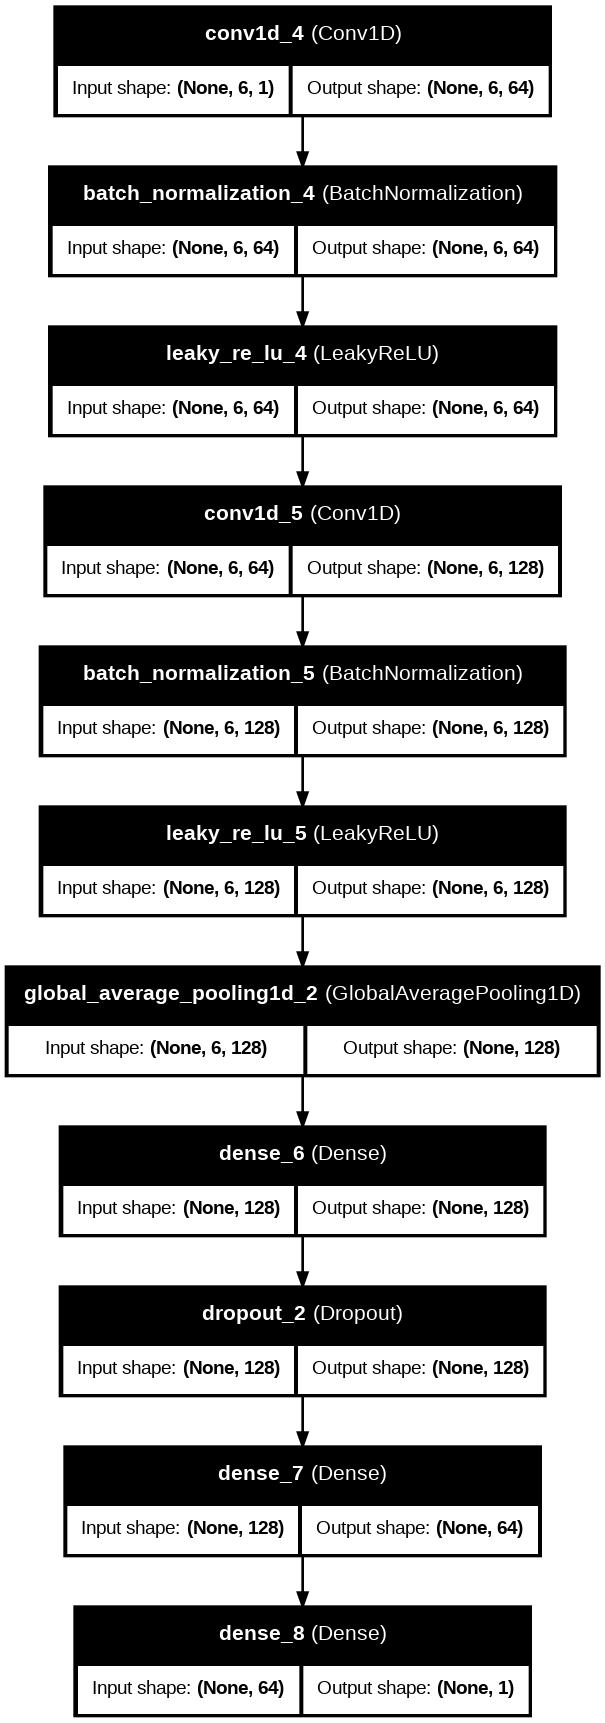

In [ ]:
from tensorflow.keras.utils import plot_model
from IPython.display import Image, display

# Generate the model plot as a PNG file
plot_model(
    model,
    to_file='model_plot.png',
    show_shapes=True,      # shows input/output dimensions
    show_layer_names=True, # shows each layer name
    expand_nested=True,
    dpi=96
)

# Display it directly in the notebook
display(Image(filename='model_plot.png'))


**Training and Evaluation**

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Implement early stopping
# training will strop if loss doesnt improve for 5 consecutives epochs
# if training stops, the weights will be restores with the best monitored metric
early_stopping = EarlyStopping(monitor='val_loss',
                               patience=10,
                               restore_best_weights=True)

# Epochs: Number of full passes through the training data.
# Batch Size: Number of samples processed before the model's weights are updated.
history = model.fit(
    X_train_scaled,        # X=inputs
    Y_train,               # Y=Target
    epochs=100,             # Number of training iterations (can be adjusted)
    batch_size=32,
    callbacks=[early_stopping],
    validation_split=0.2,  # Use 20% of training data for internal validation during training
    verbose=1              # Show training progress
)

# Test the model's performance on unseen data.
loss = model.evaluate(X_test_scaled, Y_test, verbose=0)
print(f"\nFinal Test Loss (mse): {loss:.4f}")

Epoch 1/100
52183/52183 ━━━━━━━━━━━━━━━━━━━━ 170s 3ms/step - loss: 0.1659 - val_loss: 0.1657
Epoch 2/100
52183/52183 ━━━━━━━━━━━━━━━━━━━━ 179s 3ms/step - loss: 0.1483 - val_loss: 0.1804
Epoch 3/100
52183/52183 ━━━━━━━━━━━━━━━━━━━━ 182s 3ms/step - loss: 0.1461 - val_loss: 0.1719
Epoch 4/100
52183/52183 ━━━━━━━━━━━━━━━━━━━━ 161s 3ms/step - loss: 0.1441 - val_loss: 0.1784
Epoch 5/100
52183/52183 ━━━━━━━━━━━━━━━━━━━━ 161s 3ms/step - loss: 0.1441 - val_loss: 0.1750
Epoch 6/100
52183/52183 ━━━━━━━━━━━━━━━━━━━━ 201s 3ms/step - loss: 0.1432 - val_loss: 0.1732
Epoch 7/100
52183/52183 ━━━━━━━━━━━━━━━━━━━━ 159s 3ms/step - loss: 0.1429 - val_loss: 0.1894
Epoch 8/100
52183/52183 ━━━━━━━━━━━━━━━━━━━━ 159s 3ms/step - loss: 0.1423 - val_loss: 0.2000
Epoch 9/100
52183/52183 ━━━━━━━━━━━━━━━━━━━━ 159s 3ms/step - loss: 0.1423 - val_loss: 0.1851
Epoch 10/100
52183/52183 ━━━━━━━━━━━━━━━━━━━━ 159s 3ms/step - loss: 0.1422 - val_loss: 0.1934
Epoch 11/100
52183/52183 ━━━━━━━━━━━━━━━━━━━━ 201s 3ms/step - loss: 0

NameError: name 'val_loss' is not defined

In [ ]:
print(f"\nFinal Test Loss (mse): {loss:.4f}")


Final Test Loss (mse): 0.1666


**Predict**

In [ ]:
# Predicted vs actual value
predictions = model.predict(X_test_scaled)
for i in range(len(predictions)):
  print("Predicted:", predictions[i][0], "Actual:", Y_test[i])

Se han truncado las últimas 5000 líneas del flujo de salida.
Predicted: 0.52310467 Actual: 0.2
Predicted: 1.3639956 Actual: 0.8666666666666667
Predicted: 1.164502 Actual: 0.5333333333333333
Predicted: 0.75421405 Actual: 0.6666666666666666
Predicted: 0.47179022 Actual: 0.0666666666666666
Predicted: 1.175448 Actual: 0.9666666666666668
Predicted: 0.44327733 Actual: 0.1666666666666666
Predicted: 0.6314608 Actual: 0.25
Predicted: 0.36256382 Actual: 0.25
Predicted: 0.89363706 Actual: 0.6333333333333333
Predicted: 1.4013615 Actual: 0.75
Predicted: 0.4518784 Actual: 0.4333333333333333
Predicted: 1.4146101 Actual: 1.1666666666666667
Predicted: 1.1692616 Actual: 0.9333333333333332
Predicted: 1.3842994 Actual: 0.6333333333333333
Predicted: 1.4246944 Actual: 0.6666666666666666
Predicted: 0.79260564 Actual: 0.2666666666666666
Predicted: 0.72890973 Actual: 0.3
Predicted: 0.4958108 Actual: 0.35
Predicted: 0.9774389 Actual: 0.7833333333333333
Predicted: 0.4346868 Actual: 0.2166666666666666
Predicted: 

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

Y_pred = model.predict(X_test_scaled)

# Calculate evaluation metrics
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = root_mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

# Print the results
print(f'Mean Absolute Error: {mae:.2f}')
print(f'Mean Squared Error: {mse:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')
print(f'R-squared: {r2:.2f}')

16308/16308 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step
Mean Absolute Error: 0.43
Mean Squared Error: 0.56
Root Mean Squared Error: 0.75
R-squared: 0.79


**Save the Model**

In [ ]:
# Save the model's structure and learned weights to the HDF5 file.
model.save(MODEL_SAVE_PATH)
print(f"Model successfully saved to: {MODEL_SAVE_PATH}")

Model successfully saved to: /content/drive/MyDrive/Capstone/cnn_model.h5


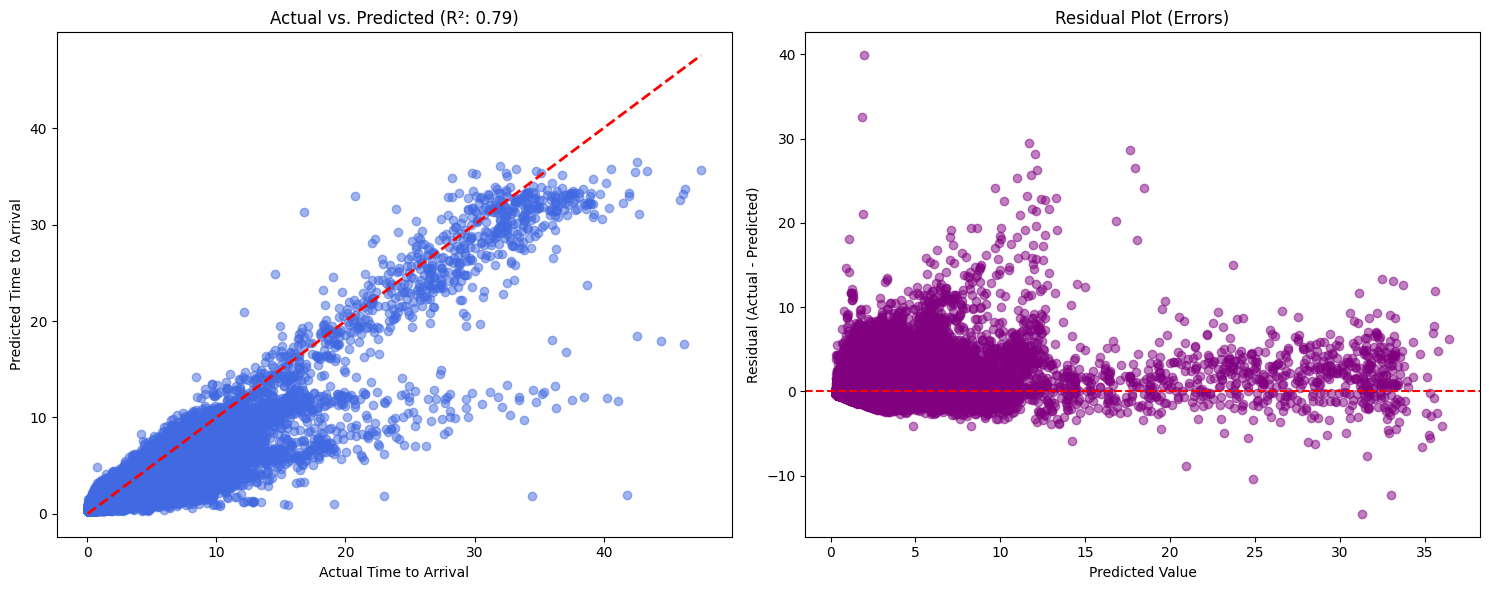

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Flatten Y_pred if it's 2D
Y_pred_flat = Y_pred.flatten()
residuals = Y_test - Y_pred_flat

plt.figure(figsize=(15, 6))

# Subplot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(Y_test, Y_pred_flat, alpha=0.5, color='royalblue')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2)
plt.title(f'Actual vs. Predicted (R²: {r2:.2f})')
plt.xlabel('Actual Time to Arrival')
plt.ylabel('Predicted Time to Arrival')

# Subplot 2: Residual Plot
plt.subplot(1, 2, 2)
plt.scatter(Y_pred_flat, residuals, alpha=0.5, color='purple')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot (Errors)')
plt.xlabel('Predicted Value')
plt.ylabel('Residual (Actual - Predicted)')

plt.tight_layout()
plt.show()